In [2]:
# Core neuroimaging + ML libraries
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

packages = [
    "numpy",
    "pandas",
    "nibabel",
    "nilearn",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "tqdm",
    "torch",
    "torchvision",
    "einops",
    "timm"
]

subprocess.check_call([sys.executable, "-m", "pip", "install"] + packages)

print('✅ Core libraries installed')

✅ Core libraries installed


In [3]:
import os

NEUROSTORM_DIR = './NeuroSTORM'

if not os.path.exists(NEUROSTORM_DIR):
    os.system('git clone https://github.com/CUHK-AIM-Group/NeuroSTORM.git')
    print('✅ NeuroSTORM cloned')
else:
    print('✅ NeuroSTORM already exists, pulling latest...')
    os.system('cd NeuroSTORM && git pull')

# Add to Python path
if NEUROSTORM_DIR not in sys.path:
    sys.path.insert(0, NEUROSTORM_DIR)

# Install repo requirements
if os.path.exists(f'{NEUROSTORM_DIR}/requirements.txt'):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           '-r', f'{NEUROSTORM_DIR}/requirements.txt'])
print('✅ NeuroSTORM requirements installed')

✅ NeuroSTORM already exists, pulling latest...
Already up to date.


✅ NeuroSTORM requirements installed


In [3]:
import os, sys, gc, torch
import numpy as np
import pandas as pd

# ── Paths ─────────────────────────────────────────────────────────────────────
RAW_DATA_DIR     = '/home/nvidia/23BRS1236/mnt/ADHD200/RawDataBIDS'
PREPROCESSED_DIR = '/home/nvidia/23BRS1236/mnt/ADHD200/preprocessed_mni'
NEUROSTORM_INPUT = '/home/nvidia/23BRS1236/mnt/ADHD200/neurostorm_data'
OUTPUT_DIR       = '/home/nvidia/23BRS1236/mnt/ADHD200/runs/adhd200'
PRETRAINED_CKPT  = '/home/nvidia/23BRS1236/mnt/ADHD200/pretrained_models/neurostorm_mae.pth'
NEUROSTORM_DIR   = './NeuroSTORM'
BATCH_SIZE    = 2
MAX_EPOCHS    = 50
LR            = 1e-4
NUM_CLASSES   = 2
PROMPT_TUNING = True
PROMPT_LEN    = 50
SITE_FOLDERS  = ['Brown','KKI','NYU','NeuroIMAGE','OHSU',
                 'Peking_1','Peking_2','Peking_3','Pittsburgh','WashU']

os.makedirs(OUTPUT_DIR, exist_ok=True)
device = torch.device('cuda')
print(f'Device : {device}')
print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'Free   : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved()) / 1e9:.1f} GB')

/home/nvidia/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Device : cuda
GPU    : NVIDIA A100-SXM4-80GB
Free   : 85.1 GB


In [4]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No CUDA GPU found — training will be very slow on CPU')

/home/nvidia/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Device : cuda
GPU    : NVIDIA A100-SXM4-80GB
VRAM   : 85.1 GB


In [5]:
import os, glob
import pandas as pd

def find_fmri_files_bids(raw_dir, site_folders):
    """
    Discovers resting-state fMRI files using the actual ADHD-200 BIDS layout:

      RawDataBIDS/
        Brown/
          sub-0026001/
            ses-1/
              func/
                sub-0026001_ses-1_task-rest_run-1_bold.nii.gz
              anat/
                sub-0026001_ses-1_run-1_T1w.nii.gz
        KKI/
          sub-XXXXXXX/ ...

    Returns a DataFrame with columns:
      subject_id  (e.g. 'sub-0026001')
      subject_num (e.g. '0026001')  ← used to match phenotype files
      site
      raw_fmri    (full path to bold.nii.gz)
    """
    records = []
    sites_found = []

    for site in site_folders:
        site_path = os.path.join(raw_dir, site)
        if not os.path.isdir(site_path):
            continue
        sites_found.append(site)

        # Each subfolder starting with 'sub-' is a subject
        subj_dirs = [d for d in sorted(os.listdir(site_path))
                     if d.startswith('sub-') and
                     os.path.isdir(os.path.join(site_path, d))]

        for subj_id in subj_dirs:
            subj_path = os.path.join(site_path, subj_id)

            # Search for func/*.nii.gz anywhere under subject folder
            func_files = glob.glob(
                os.path.join(subj_path, '**', 'func', '*bold*.nii.gz'),
                recursive=True
            )
            # Fallback: any rest nii.gz
            if not func_files:
                func_files = glob.glob(
                    os.path.join(subj_path, '**', '*rest*.nii.gz'),
                    recursive=True
                )

            if func_files:
                # Pick largest file (most timepoints)
                func_files.sort(key=lambda x: os.path.getsize(x), reverse=True)
                # Strip 'sub-' prefix to get numeric ID for phenotype matching
                subj_num = subj_id.replace('sub-', '')
                records.append({
                    'subject_id' : subj_id,   # e.g. 'sub-0026001'
                    'subject_num': subj_num,  # e.g. '0026001'
                    'site'       : site,
                    'raw_fmri'   : func_files[0],
                })

    df = pd.DataFrame(records)
    print(f'Sites found        : {sites_found}')
    print(f'Subjects with fMRI : {len(df)}')
    if len(df) > 0:
        print(f'\nPer-site counts:')
        print(df['site'].value_counts().to_string())
        print(f'\nExample rows:')
        print(df[['subject_id', 'site', 'raw_fmri']].head(3).to_string(index=False))
    return df


subjects_df = find_fmri_files_bids(RAW_DATA_DIR, SITE_FOLDERS)

if len(subjects_df) == 0:
    print('\n❌ No subjects found. Run the diagnostic cell to check folder structure.')
else:
    print(f'\n✅ Found {len(subjects_df)} subjects across {subjects_df["site"].nunique()} sites')

Sites found        : ['Brown', 'KKI', 'NYU', 'NeuroIMAGE', 'OHSU', 'Peking_1', 'Peking_2', 'Peking_3', 'Pittsburgh', 'WashU']
Subjects with fMRI : 955

Per-site counts:
site
NYU           257
Peking_1      136
OHSU          113
Pittsburgh     98
KKI            83
NeuroIMAGE     73
Peking_2       67
WashU          60
Peking_3       42
Brown          26

Example rows:
 subject_id  site                                                                                                                  raw_fmri
sub-0026001 Brown /home/nvidia/23BRS1236/mnt/ADHD200/RawDataBIDS/Brown/sub-0026001/ses-1/func/sub-0026001_ses-1_task-rest_run-1_bold.nii.gz
sub-0026002 Brown /home/nvidia/23BRS1236/mnt/ADHD200/RawDataBIDS/Brown/sub-0026002/ses-1/func/sub-0026002_ses-1_task-rest_run-1_bold.nii.gz
sub-0026004 Brown /home/nvidia/23BRS1236/mnt/ADHD200/RawDataBIDS/Brown/sub-0026004/ses-1/func/sub-0026004_ses-1_task-rest_run-1_bold.nii.gz

✅ Found 955 subjects across 10 sites


In [6]:
import pandas as pd
import os, glob

def load_phenotype_adhd200(raw_dir, site_folders):
    """
    Loads all phenotype files for ADHD-200, handling two formats:

    Format A — *_phenotypic.csv (most sites):
      Columns: 'ScanDir ID', 'DX'  (DX: 0=control, 1=ADHD-combined,
                                         2=ADHD-inattentive, 3=ADHD-hyperactive)
      Example files: KKI_phenotypic.csv, NYU_phenotypic.csv

    Format B — participants.tsv (BIDS, Peking_2, Peking_3, KKI, NYU, Pittsburgh):
      Columns: 'participant_id' (sub-XXXXXXX), 'diagnosis'
      These live inside the site subfolder or at root level.

    We prefer the _phenotypic.csv when both exist for a site, as it has
    more subjects and clearer DX coding.

    Returns DataFrame with columns:
      subject_num (e.g. '0026001'), label (0 or 1)
    """
    all_records = []

    for site in site_folders:
        site_path = os.path.join(raw_dir, site)

        # ── Search order: phenotypic.csv at root → phenotypic.csv in site folder
        #                 → participants.tsv in site folder → participants.tsv at root
        candidates = (
            glob.glob(os.path.join(raw_dir, f'{site}_phenotypic.csv')) +
            glob.glob(os.path.join(raw_dir, f'{site}_TestRelease_phenotypic.csv')) +
            (glob.glob(os.path.join(site_path, '*phenotypic*.csv'))
             if os.path.isdir(site_path) else []) +
            (glob.glob(os.path.join(site_path, 'participants.tsv'))
             if os.path.isdir(site_path) else []) +
            glob.glob(os.path.join(raw_dir, f'{site}_participants.tsv'))
        )
        candidates = list(dict.fromkeys(candidates))  # deduplicate, keep order

        if not candidates:
            print(f'  ⚠️  {site}: no phenotype file found')
            continue

        pheno_file = candidates[0]
        ext = os.path.splitext(pheno_file)[1].lower()
        sep = '\t' if ext in ['.tsv', '.txt'] else ','

        try:
            df = pd.read_csv(pheno_file, sep=sep, low_memory=False)
            df.columns = df.columns.str.strip()  # Remove stray whitespace
        except Exception as e:
            print(f'  ⚠️  {site}: failed to read {pheno_file}: {e}')
            continue

        # ── Detect format and normalise columns ──────────────────────────────
        records_before = len(all_records)

        if 'ScanDir ID' in df.columns and 'DX' in df.columns:
            # Format A: *_phenotypic.csv
            df['subject_num'] = df['ScanDir ID'].astype(str).str.strip().str.zfill(7)
            df['label'] = df['DX'].apply(
                lambda x: 0 if str(x).strip() in ['0', '0.0'] else
                          (1 if str(x).strip() not in ['', 'nan', 'NaN'] else -1)
            )
            df['site'] = site
            valid = df[df['label'] >= 0][['subject_num', 'site', 'label']]
            all_records.append(valid)
            print(f'  ✅ {site}: {len(valid)} subjects from {os.path.basename(pheno_file)} '
                  f'(Format A: ScanDir ID + DX)')

        elif 'participant_id' in df.columns and 'diagnosis' in df.columns:
            # Format B: participants.tsv
            df['subject_num'] = (df['participant_id'].astype(str)
                                 .str.strip()
                                 .str.replace('sub-', '', regex=False)
                                 .str.zfill(7))
            df['label'] = df['diagnosis'].apply(
                lambda x: 0 if str(x).strip() in ['0', '0.0', 'control', 'Control',
                                                   'TDC', 'Typical', 'TD'] else
                          (1 if str(x).strip() not in ['', 'nan', 'NaN'] else -1)
            )
            df['site'] = site
            valid = df[df['label'] >= 0][['subject_num', 'site', 'label']]
            all_records.append(valid)
            print(f'  ✅ {site}: {len(valid)} subjects from {os.path.basename(pheno_file)} '
                  f'(Format B: participant_id + diagnosis)')

        else:
            print(f'  ⚠️  {site}: unrecognised columns in {os.path.basename(pheno_file)}')
            print(f'       Columns found: {list(df.columns[:8])}')
            # Last-resort: print all columns so user can report back
            print(f'       All columns: {list(df.columns)}')

    if not all_records:
        print('\n❌ No phenotype records loaded at all.')
        return pd.DataFrame(columns=['subject_num', 'site', 'label'])

    pheno = pd.concat(all_records, ignore_index=True)
    pheno = pheno.drop_duplicates('subject_num').reset_index(drop=True)

    print(f'\nTotal labelled subjects: {len(pheno)}')
    print(f'Label distribution:')
    print(pheno['label'].value_counts().rename({0: 'Control (0)', 1: 'ADHD (1)'}).to_string())
    return pheno


pheno_df = load_phenotype_adhd200(RAW_DATA_DIR, SITE_FOLDERS)

  ✅ Brown: 26 subjects from Brown_TestRelease_phenotypic.csv (Format A: ScanDir ID + DX)
  ✅ KKI: 83 subjects from KKI_phenotypic.csv (Format A: ScanDir ID + DX)
  ✅ NYU: 222 subjects from NYU_phenotypic.csv (Format A: ScanDir ID + DX)
  ✅ NeuroIMAGE: 48 subjects from NeuroIMAGE_phenotypic.csv (Format A: ScanDir ID + DX)
  ✅ OHSU: 79 subjects from OHSU_phenotypic.csv (Format A: ScanDir ID + DX)
  ✅ Peking_1: 85 subjects from Peking_1_phenotypic.csv (Format A: ScanDir ID + DX)
  ⚠️  Peking_2: unrecognised columns in participants.tsv
       Columns found: ['participant_id', 'gender', 'age', 'handedness', 'dx', 'secondary_dx', 'adhd_measure', 'adhd_index']
       All columns: ['participant_id', 'gender', 'age', 'handedness', 'dx', 'secondary_dx', 'adhd_measure', 'adhd_index', 'inattentive', 'hyper_impulsive', 'iq_measure', 'verbal_iq', 'performance_iq', 'full2_iq', 'full4_iq', 'med_status', 'qc_rest_1', 'qc_rest_2', 'qc_rest_3', 'qc_rest_4', 'qc_anatomical_1', 'qc_anatomical_2']
  ⚠️  Pek

In [10]:
import pandas as pd

# subjects_df has 'subject_num' (e.g. '0026001')
# pheno_df   has 'subject_num' (e.g. '0026001') and 'label'
# Both were zero-padded to 7 digits in their respective cells

# Ensure subject_num is zero-padded consistently in subjects_df too
subjects_df['subject_num'] = subjects_df['subject_num'].astype(str).str.zfill(7)
pheno_df['subject_num']    = pheno_df['subject_num'].astype(str).str.zfill(7)

merged = subjects_df.merge(
    pheno_df[['subject_num', 'label']],
    on='subject_num',
    how='left'
)

print(f'Subjects with fMRI            : {len(subjects_df)}')
print(f'Subjects with phenotype labels: {len(pheno_df)}')
print(f'After merge (total)           : {len(merged)}')
print(f'Missing labels                : {merged["label"].isna().sum()}')

# Show a few unmatched subjects so you can diagnose ID mismatches
unmatched = merged[merged['label'].isna()]
if len(unmatched) > 0:
    print(f'\nFirst 5 unmatched subject_nums (fMRI exists but no phenotype):')
    print(unmatched[['subject_num', 'site']].head(5).to_string(index=False))
    print(f'\nFirst 5 phenotype subject_nums for same site:')
    sample_site = unmatched.iloc[0]['site']
    print(pheno_df[pheno_df['site'] == sample_site]['subject_num'].head(5).to_string())

# Drop rows without labels
merged = merged.dropna(subset=['label'])
merged['label'] = merged['label'].astype(int)

print(f'\nFinal usable subjects: {len(merged)}')
print(merged['label'].value_counts().rename({0: 'Control', 1: 'ADHD'}).to_string())
print(f'\nPer-site breakdown:')
print(merged.groupby(['site', 'label']).size().unstack(fill_value=0)
      .rename(columns={0: 'Control', 1: 'ADHD'}).to_string())

# This feeds into Cell 8 (preprocessing)
merged_ok = merged.copy()
print('\n✅ merged_ok ready for preprocessing (Cell 8)')

Subjects with fMRI            : 955
Subjects with phenotype labels: 632
After merge (total)           : 955
Missing labels                : 329

First 5 unmatched subject_nums (fMRI exists but no phenotype):
subject_num site
    0021002  NYU
    0021003  NYU
    0021005  NYU
    0021006  NYU
    0021007  NYU

First 5 phenotype subject_nums for same site:
109    1000804
110    1023964
111    1057962
112    1099481
113    1127915

Final usable subjects: 626
label
Control    374
ADHD       252

Per-site breakdown:
label       Control  ADHD
site                     
Brown             0    26
KKI              61    22
NYU              98   118
NeuroIMAGE       23    25
OHSU             42    37
Peking_1         61    24
Pittsburgh       89     0

✅ merged_ok ready for preprocessing (Cell 8)


In [14]:
import os
import nibabel as nib
import numpy as np
from tqdm import tqdm
from joblib import Parallel, delayed
from nilearn import image as nilimage
from nilearn.datasets import load_mni152_template

# -------------------------------------------------------
# Target space: MNI152 2mm
# -------------------------------------------------------
MNI_TEMPLATE = load_mni152_template(resolution=2)

# -------------------------------------------------------
# Preprocess one subject
# -------------------------------------------------------
def preprocess_subject(raw_path, out_path):

    # Skip if already processed
    if os.path.exists(out_path):
        return True

    try:
        img = nib.load(raw_path)

        # Load as float32 (faster and lower RAM)
        data = img.get_fdata(dtype=np.float32)

        # Remove first 5 TRs
        if data.ndim == 4 and data.shape[-1] > 10:
            data = data[..., 5:]

        img = nib.Nifti1Image(data, img.affine, img.header)

        # Read TR
        try:
            tr = img.header.get_zooms()[3]
            if tr <= 0 or tr > 10:
                tr = 2.0
        except Exception:
            tr = 2.0

        # Resample to MNI
        img_mni = nilimage.resample_img(
            img,
            target_affine=MNI_TEMPLATE.affine,
            target_shape=MNI_TEMPLATE.shape[:3],
            interpolation="continuous",
            copy=False,
            force_resample=False
        )

        # Clean signal
        img_clean = nilimage.clean_img(
            img_mni,
            detrend=True,
            standardize="zscore_sample",
            low_pass=0.1,
            high_pass=0.01,
            t_r=tr
        )

        os.makedirs(os.path.dirname(out_path), exist_ok=True)

        nib.save(img_clean, out_path)

        return True

    except Exception as e:
        print(f"\nFailed: {raw_path}\n{e}")
        return False


# -------------------------------------------------------
# Parallel processing
# -------------------------------------------------------

print(f"Preprocessing {len(merged)} subjects...")

def process_subject_safe(raw_path, out_path):
    """
    Self-contained function: loads MNI template INSIDE the worker
    so joblib can pickle it cleanly across processes.
    """
    import os, nibabel as nib, numpy as np
    from nilearn import image as nilimage
    from nilearn.datasets import load_mni152_template

    if os.path.exists(out_path):
        return True
    try:
        # Load template fresh in each worker process
        mni = load_mni152_template(resolution=2)

        img = nib.load(raw_path)
        data = img.get_fdata(dtype=np.float32)
        if data.ndim == 4 and data.shape[-1] > 10:
            data = data[..., 5:]
        img = nib.Nifti1Image(data, img.affine, img.header)

        try:
            tr = img.header.get_zooms()[3]
            if tr <= 0 or tr > 10:
                tr = 2.0
        except Exception:
            tr = 2.0

        img_mni = nilimage.resample_img(
            img,
            target_affine=mni.affine,
            target_shape=mni.shape[:3],
            interpolation="continuous",
            copy=False,
            force_resample=False
        )
        img_clean = nilimage.clean_img(
            img_mni,
            detrend=True,
            standardize="zscore_sample",
            low_pass=0.1,
            high_pass=0.01,
            t_r=tr
        )
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        nib.save(img_clean, out_path)
        return True

    except Exception as e:
        print(f"\nFailed: {raw_path}\n{e}")
        return False


# Build list of (raw_path, out_path) tuples
job_args = []
for _, row in merged.iterrows():
    out_fname = f"{row['subject_id']}_{row['site']}_preproc.nii.gz"
    out_path  = os.path.join(PREPROCESSED_DIR, row['site'], out_fname)
    job_args.append((row['raw_fmri'], out_path))

success_flags = Parallel(
    n_jobs=8,           # Start conservative; increase if RAM is fine
    backend="loky",
    verbose=5
)(
    delayed(process_subject_safe)(raw, out)
    for raw, out in job_args
)

# ── Save paths ────────────────────────────────────────────────────────────────
merged["preproc_ok"]   = success_flags
merged["preproc_path"] = [out for _, out in job_args]

merged_ok = merged[merged["preproc_ok"] == True].copy()
print(f"\n✅ Successfully preprocessed {len(merged_ok)} / {len(merged)} subjects")

Preprocessing 626 subjects...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.



✅ Successfully preprocessed 626 / 626 subjects


[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    1.3s
[Parallel(n_jobs=8)]: Done  72 tasks      | elapsed:    1.4s
[Parallel(n_jobs=8)]: Done 562 tasks      | elapsed:    1.4s
[Parallel(n_jobs=8)]: Done 626 out of 626 | elapsed:    1.4s finished


In [18]:
import os

# Check 1: What does merged look like after Cell 8?
print("=== merged dataframe ===")
print(f"Total rows       : {len(merged)}")
print(f"Columns          : {list(merged.columns)}")
print(f"preproc_ok values: {merged['preproc_ok'].value_counts().to_dict()}")
print(f"merged_ok rows   : {len(merged_ok)}")

# Check 2: Do the files actually exist on disk?
print("\n=== Files on disk ===")
n_exist = sum(os.path.exists(p) for p in merged['preproc_path'])
print(f"Files that exist : {n_exist} / {len(merged)}")

# Check 3: Show first few paths and whether they exist
print("\n=== First 5 preproc_paths ===")
for _, row in merged.head(5).iterrows():
    exists = os.path.exists(row['preproc_path'])
    ok     = row['preproc_ok']
    print(f"  exists={exists}  preproc_ok={ok}  path={row['preproc_path']}")

# Check 4: What is actually in PREPROCESSED_DIR?
print(f"\n=== Contents of PREPROCESSED_DIR ===")
for site in os.listdir(PREPROCESSED_DIR):
    site_path = os.path.join(PREPROCESSED_DIR, site)
    if os.path.isdir(site_path):
        files = os.listdir(site_path)
        print(f"  {site}: {len(files)} files")
        if files:
            print(f"    example: {files[0]}")

=== merged dataframe ===
Total rows       : 626
Columns          : ['subject_id', 'subject_num', 'site', 'raw_fmri', 'label', 'preproc_ok', 'preproc_path']
preproc_ok values: {True: 626}
merged_ok rows   : 0

=== Files on disk ===
Files that exist : 626 / 626

=== First 5 preproc_paths ===
  exists=True  preproc_ok=True  path=/home/nvidia/23BRS1236/mnt/ADHD200/preprocessed_mni/Brown/sub-0026001_Brown_preproc.nii.gz
  exists=True  preproc_ok=True  path=/home/nvidia/23BRS1236/mnt/ADHD200/preprocessed_mni/Brown/sub-0026002_Brown_preproc.nii.gz
  exists=True  preproc_ok=True  path=/home/nvidia/23BRS1236/mnt/ADHD200/preprocessed_mni/Brown/sub-0026004_Brown_preproc.nii.gz
  exists=True  preproc_ok=True  path=/home/nvidia/23BRS1236/mnt/ADHD200/preprocessed_mni/Brown/sub-0026005_Brown_preproc.nii.gz
  exists=True  preproc_ok=True  path=/home/nvidia/23BRS1236/mnt/ADHD200/preprocessed_mni/Brown/sub-0026009_Brown_preproc.nii.gz

=== Contents of PREPROCESSED_DIR ===
  Brown: 26 files
    example: 

In [7]:
import torch

print(torch.cuda.is_available())

True


In [8]:
import os
import psutil

print("Logical CPUs :", os.cpu_count())
print("Physical CPUs:", psutil.cpu_count(logical=False))

Logical CPUs : 96
Physical CPUs: 96


In [22]:
import nibabel as nib
import numpy as np

# ── Rebuild merged_ok directly from merged (all 626 subjects) ─────────────────
# merged has preproc_ok=True and files exist for all 626 — use it directly
merged_ok = merged[merged['preproc_ok'] == True].copy()
print(f"Restored merged_ok: {len(merged_ok)} subjects")

# ── Validate files (accept any 4D volume at 2mm — no strict shape requirement) 
print('\nChecking first 8 subjects:')
valid_rows = []
shape_counts = {}

for i, (_, row) in enumerate(merged_ok.iterrows()):
    try:
        img   = nib.load(row['preproc_path'])
        shape = img.shape
        zooms = img.header.get_zooms()

        vox_ok   = all(abs(float(z) - 2.0) < 0.1 for z in zooms[:3])
        is_valid = (img.ndim == 4 and shape[3] > 5 and vox_ok)
        valid_rows.append(is_valid)
        shape_counts[shape[:3]] = shape_counts.get(shape[:3], 0) + 1

        if i < 8:
            status = '✅' if is_valid else '❌'
            print(f'  {status} {row["subject_id"]:15s}  shape={shape}  '
                  f'vox={tuple(round(float(z),1) for z in zooms[:3])}')
    except Exception as e:
        print(f'  ❌ {row["subject_id"]}: {e}')
        valid_rows.append(False)

merged_ok['shape_ok'] = valid_rows
merged_ok = merged_ok[merged_ok['shape_ok']].copy()

print(f'\nShape distribution:')
for s, c in sorted(shape_counts.items(), key=lambda x: -x[1]):
    print(f'  {str(s):25s}: {c} subjects')

print(f'\n✅ Valid subjects ready for Cell 10: {len(merged_ok)}')

Restored merged_ok: 626 subjects

Checking first 8 subjects:
  ✅ sub-0026001      shape=(99, 117, 95, 246)  vox=(2.0, 2.0, 2.0)
  ✅ sub-0026002      shape=(99, 117, 95, 246)  vox=(2.0, 2.0, 2.0)
  ✅ sub-0026004      shape=(99, 117, 95, 246)  vox=(2.0, 2.0, 2.0)
  ✅ sub-0026005      shape=(99, 117, 95, 246)  vox=(2.0, 2.0, 2.0)
  ✅ sub-0026009      shape=(99, 117, 95, 246)  vox=(2.0, 2.0, 2.0)
  ✅ sub-0026014      shape=(99, 117, 95, 246)  vox=(2.0, 2.0, 2.0)
  ✅ sub-0026015      shape=(99, 117, 95, 246)  vox=(2.0, 2.0, 2.0)
  ✅ sub-0026016      shape=(99, 117, 95, 246)  vox=(2.0, 2.0, 2.0)

Shape distribution:
  (99, 117, 95)            : 626 subjects

✅ Valid subjects ready for Cell 10: 626


In [25]:
import nibabel as nib
import numpy as np
import os
from tqdm import tqdm

def nii_to_npy(nii_path, npy_path):
    """Save as .npy instead of .pt — no torch dependency, faster, no version issues."""
    if os.path.exists(npy_path):
        try:
            np.load(npy_path, mmap_mode='r')  # verify readable
            return True
        except Exception:
            os.remove(npy_path)

    try:
        img  = nib.load(nii_path)
        data = img.get_fdata(dtype=np.float32)  # (X, Y, Z, T)

        if data.ndim == 3:
            data = data[..., np.newaxis]

        # Move time axis first: (T, X, Y, Z)
        data = np.moveaxis(data, -1, 0)

        # Crop/pad to fixed shape
        target_shape = (data.shape[0], 99, 117, 95)
        cropped = np.zeros(target_shape, dtype=np.float32)
        sx = min(data.shape[1], 99)
        sy = min(data.shape[2], 117)
        sz = min(data.shape[3], 95)
        cropped[:, :sx, :sy, :sz] = data[:, :sx, :sy, :sz]
        data = cropped

        # Normalize to [-1, 1] then quantise to int8
        vmin, vmax = data.min(), data.max()
        if vmax - vmin > 1e-6:
            data = 2.0 * (data - vmin) / (vmax - vmin) - 1.0
        data_int8 = (data * 127).clip(-128, 127).astype(np.int8)

        os.makedirs(os.path.dirname(npy_path), exist_ok=True)
        np.save(npy_path, data_int8)  # saves as .npy — no torch needed
        return True

    except Exception as e:
        print(f'  ⚠️  {nii_path}: {e}')
        return False


print('Converting NIfTI → int8 .npy volumes for NeuroSTORM...')
npy_paths, npy_ok = [], []

for _, row in tqdm(manifest.iterrows(), total=len(manifest)):
    npy_fname = f"{row['subject_id']}_{row['site']}.npy"
    npy_path  = os.path.join(NEUROSTORM_INPUT, row['site'], npy_fname)
    ok = nii_to_npy(row['preproc_path'], npy_path)
    npy_paths.append(npy_path)
    npy_ok.append(ok)

manifest['pt_path'] = npy_paths   # keep column name 'pt_path' so rest of notebook works
manifest['pt_ok']   = npy_ok
manifest_final = manifest[manifest['pt_ok']].copy()
manifest_final.to_csv('./adhd200_manifest_final.csv', index=False)

print(f'\n✅ Converted: {manifest["pt_ok"].sum()} / {len(manifest)}')
print('Manifest saved → adhd200_manifest_final.csv')

Converting NIfTI → int8 .npy volumes for NeuroSTORM...


100%|██████████| 626/626 [33:35<00:00,  3.22s/it]


✅ Converted: 626 / 626
Manifest saved → adhd200_manifest_final.csv


In [28]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random

class ADHD200Dataset(Dataset):
    def __init__(self, df, split='train', n_timepoints=50, augment=True):
        self.df     = df[df['split'] == split].reset_index(drop=True)
        self.n_tp   = n_timepoints
        self.augment = augment and (split == 'train')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load .npy file (int8) and convert to float32
        data   = np.load(row['pt_path']).astype(np.float32) / 127.0  # (T, X, Y, Z)
        tensor = torch.from_numpy(data)

        T = tensor.shape[0]
        if T >= self.n_tp:
            if self.augment:
                start = random.randint(0, T - self.n_tp)
            else:
                start = (T - self.n_tp) // 2
            tensor = tensor[start : start + self.n_tp]
        else:
            pad    = torch.zeros(self.n_tp - T, *tensor.shape[1:])
            tensor = torch.cat([tensor, pad], dim=0)

        label = torch.tensor(int(row['label']), dtype=torch.long)
        return tensor, label


# ── Instantiate datasets ──────────────────────────────────────────────────────
train_dataset = ADHD200Dataset(manifest_final, split='train', n_timepoints=50)
val_dataset   = ADHD200Dataset(manifest_final, split='val',   n_timepoints=50, augment=False)
test_dataset  = ADHD200Dataset(manifest_final, split='test',  n_timepoints=50, augment=False)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,
                          num_workers=2, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=2, shuffle=False,
                          num_workers=2, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=2, shuffle=False,
                          num_workers=2, pin_memory=False)

# ── Sanity check ──────────────────────────────────────────────────────────────
batch_x, batch_y = next(iter(train_loader))
print(f'Batch shape : {batch_x.shape}   (B, T, X, Y, Z)')
print(f'Labels      : {batch_y.tolist()}')
print(f'Value range : [{batch_x.min():.3f}, {batch_x.max():.3f}]')
print(f'Memory per batch : {batch_x.element_size() * batch_x.nelement() / 1e6:.1f} MB')

Batch shape : torch.Size([2, 50, 99, 117, 95])   (B, T, X, Y, Z)
Labels      : [0, 1]
Value range : [-0.913, 0.992]
Memory per batch : 440.2 MB


In [4]:
# All 626 subjects are already preprocessed and converted to .npy
# Just reload the manifest CSV directly — no need to re-run Cells 5-11
manifest_final = pd.read_csv('./adhd200_manifest_final.csv')

print(f'Subjects loaded : {len(manifest_final)}')
print(f'Splits:')
for split, grp in manifest_final.groupby('split'):
    vc = grp['label'].value_counts()
    print(f'  {split:5s} | ADHD={vc.get(1,0)}  Control={vc.get(0,0)}')
print(f'\nSample pt_path: {manifest_final["pt_path"].iloc[0]}')
print(f'File exists   : {os.path.exists(manifest_final["pt_path"].iloc[0])}')

Subjects loaded : 626
Splits:
  test  | ADHD=25  Control=38
  train | ADHD=201  Control=299
  val   | ADHD=26  Control=37

Sample pt_path: /home/nvidia/23BRS1236/mnt/ADHD200/neurostorm_data/NYU/sub-4562206_NYU.npy
File exists   : True


In [5]:
from torch.utils.data import Dataset, DataLoader
import random

class ADHD200Dataset(Dataset):
    def __init__(self, df, split='train', n_timepoints=50, augment=True):
        self.df      = df[df['split'] == split].reset_index(drop=True)
        self.n_tp    = n_timepoints
        self.augment = augment and (split == 'train')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        data   = np.load(row['pt_path']).astype(np.float32) / 127.0
        tensor = torch.from_numpy(data)
        T = tensor.shape[0]
        if T >= self.n_tp:
            start = random.randint(0, T - self.n_tp) if self.augment else (T - self.n_tp) // 2
            tensor = tensor[start:start + self.n_tp]
        else:
            tensor = torch.cat([tensor, torch.zeros(self.n_tp - T, *tensor.shape[1:])], dim=0)
        return tensor, torch.tensor(int(row['label']), dtype=torch.long)

train_loader = DataLoader(ADHD200Dataset(manifest_final, 'train', 50),
                          batch_size=2, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(ADHD200Dataset(manifest_final, 'val',   50, augment=False),
                          batch_size=2, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(ADHD200Dataset(manifest_final, 'test',  50, augment=False),
                          batch_size=2, shuffle=False, num_workers=0, pin_memory=False)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')
print('DataLoaders ready ✅  (num_workers=0 avoids subprocess memory issues)')

Train batches : 250
Val batches   : 32
Test batches  : 32
DataLoaders ready ✅  (num_workers=0 avoids subprocess memory issues)


In [10]:
import torch.nn as nn

class Lightweight3DCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.spatial_encoder = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=5, stride=3, padding=2),
            nn.BatchNorm3d(16), nn.ReLU(),
            nn.Conv3d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm3d(32), nn.ReLU(),
            nn.Conv3d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm3d(64), nn.ReLU(),
            nn.AdaptiveAvgPool3d((2, 2, 2))
        )
        self.temporal_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(64 * 8, 256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        B, T, X, Y, Z = x.shape
        x = x[:, ::2, :, :, :]
        B, Ts, X, Y, Z = x.shape
        x     = x.reshape(B * Ts, 1, X, Y, Z)
        feats = self.spatial_encoder(x)
        feats = feats.reshape(B, Ts, -1)
        feats = self.temporal_pool(feats.permute(0, 2, 1)).squeeze(-1)
        return self.classifier(feats)

gc.collect()
torch.cuda.empty_cache()

model = Lightweight3DCNN(num_classes=NUM_CLASSES).to(device)
print(f'Model params : {sum(p.numel() for p in model.parameters()):,}')
print(f'GPU after model load : {torch.cuda.memory_allocated() / 1e9:.2f} GB')

# Verify with tiny tensor — NOT full size
with torch.no_grad():
    dummy = torch.zeros(2, 25, 99, 117, 95, device=device)
    out   = model(dummy)
    print(f'Forward pass OK: {tuple(dummy.shape)} → {tuple(out.shape)} ✅')
    del dummy, out

torch.cuda.empty_cache()
print(f'GPU after test : {torch.cuda.memory_allocated() / 1e9:.2f} GB')

Model params : 203,298
GPU after model load : 0.00 GB
Forward pass OK: (2, 25, 99, 117, 95) → (2, 2) ✅
GPU after test : 0.01 GB


In [22]:
import sys, os, torch, torch.nn as nn

# ── Fallback 3D CNN (used because NeuroSTORM requires PyTorch >= 2.6) ─────────
class Lightweight3DCNN(nn.Module):
    """
    A compact 3D CNN for ADHD classification.
    Processes spatial 3D brain volumes, averages over time, then classifies.
    Input shape: (B, T, X, Y, Z)
    """
    def __init__(self, num_classes=2):
        super().__init__()
        self.spatial_encoder = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=5, stride=3, padding=2),
            nn.BatchNorm3d(16), nn.ReLU(),
            nn.Conv3d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm3d(32), nn.ReLU(),
            nn.Conv3d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm3d(64), nn.ReLU(),
            nn.AdaptiveAvgPool3d((2, 2, 2))   # always outputs (64, 2, 2, 2)
        )
        self.temporal_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(64 * 8, 256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # x: (B, T, X, Y, Z)
        B, T, X, Y, Z = x.shape
        # Sample every 2nd frame to halve memory usage
        x = x[:, ::2, :, :, :]
        B, Ts, X, Y, Z = x.shape
        # Merge batch and time dims → process each frame as a 3D volume
        x = x.reshape(B * Ts, 1, X, Y, Z)
        feats = self.spatial_encoder(x)           # (B*Ts, 64, 2, 2, 2)
        feats = feats.reshape(B, Ts, -1)          # (B, Ts, 512)
        # Pool over time dimension
        feats = self.temporal_pool(
            feats.permute(0, 2, 1)                # (B, 512, Ts)
        ).squeeze(-1)                              # (B, 512)
        return self.classifier(feats)              # (B, num_classes)


# ── Build and move to GPU ─────────────────────────────────────────────────────
model = Lightweight3DCNN(num_classes=NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model    : Lightweight3DCNN (fallback — NeuroSTORM needs PyTorch >= 2.6)')
print(f'Params   : {total_params:,}')
print(f'Device   : {device}')

# ── Quick forward pass to verify shapes work ──────────────────────────────────
with torch.no_grad():
    dummy = torch.zeros(2, 50, 99, 117, 95).to(device)
    out   = model(dummy)
    print(f'Test forward pass: input {tuple(dummy.shape)} → output {tuple(out.shape)} ✅')

# ── Optionally upgrade PyTorch to use real NeuroSTORM later ───────────────────
print('\nTo use the real NeuroSTORM model, upgrade PyTorch:')
print('  pip install torch==2.6.0 torchvision --index-url https://download.pytorch.org/whl/cu121')
print('Then re-run from Cell 2 onwards.')

Model    : Lightweight3DCNN (fallback — NeuroSTORM needs PyTorch >= 2.6)
Params   : 203,298
Device   : cuda
Test forward pass: input (2, 50, 99, 117, 95) → output (2, 2) ✅

To use the real NeuroSTORM model, upgrade PyTorch:
  pip install torch==2.6.0 torchvision --index-url https://download.pytorch.org/whl/cu121
Then re-run from Cell 2 onwards.


In [12]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

# Class-weighted loss for ADHD-200 imbalance
label_counts = manifest_final[manifest_final['split']=='train']['label'].value_counts().sort_index()
n_ctrl, n_adhd = label_counts.get(0, 1), label_counts.get(1, 1)
weight = torch.tensor([1.0/n_ctrl, 1.0/n_adhd], dtype=torch.float32)
weight = weight / weight.sum()
criterion = nn.CrossEntropyLoss(weight=weight.to(device))

# Only pass trainable params to optimiser
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.AdamW(params, lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS, eta_min=1e-6)

print(f'Loss     : CrossEntropy (weights: ctrl={weight[0]:.3f}, adhd={weight[1]:.3f})')
print(f'Optimizer: AdamW  lr={LR}  wd=1e-4')
print(f'Scheduler: CosineAnnealingLR  epochs={MAX_EPOCHS}')
print(f'Trainable params: {sum(p.numel() for p in params):,}')

Loss     : CrossEntropy (weights: ctrl=0.402, adhd=0.598)
Optimizer: AdamW  lr=0.0001  wd=1e-4
Scheduler: CosineAnnealingLR  epochs=50
Trainable params: 203,298


In [13]:
import torch
import os
from tqdm import tqdm

def run_epoch(model, loader, criterion, optimizer=None, device='cuda'):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for x, y in tqdm(loader, leave=False, desc='train' if is_train else 'eval'):
            x, y = x.to(device), y.to(device)

            logits = model(x)
            loss   = criterion(logits, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            preds = logits.argmax(dim=1)
            correct   += (preds == y).sum().item()
            total     += y.size(0)
            total_loss += loss.item() * y.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(y.cpu().tolist())

    return total_loss / total, correct / total, all_preds, all_labels


# ── Main training loop ───────────────────────────────────────────────────────
best_val_acc = 0.0
best_ckpt    = os.path.join(OUTPUT_DIR, 'best_model.pth')
history      = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

print(f'Training for {MAX_EPOCHS} epochs on {device}...\n')

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, tr_acc, _, _ = run_epoch(model, train_loader, criterion,
                                       optimizer=optimizer, device=device)
    vl_loss, vl_acc, _, _ = run_epoch(model, val_loader, criterion,
                                       optimizer=None, device=device)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save({'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'val_acc': vl_acc}, best_ckpt)
        mark = ' ← best'
    else:
        mark = ''

    print(f'Epoch {epoch:3d}/{MAX_EPOCHS} | '
          f'tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.3f} | '
          f'val_loss={vl_loss:.4f}  val_acc={vl_acc:.3f}{mark}')

print(f'\n✅ Training complete. Best val acc: {best_val_acc:.3f}')
print(f'   Checkpoint saved → {best_ckpt}')

Training for 50 epochs on cuda...



Epoch   1/50 | tr_loss=0.6999  tr_acc=0.548 | val_loss=0.7022  val_acc=0.587 ← best


Epoch   2/50 | tr_loss=0.7100  tr_acc=0.608 | val_loss=0.6354  val_acc=0.714 ← best


Epoch   3/50 | tr_loss=0.7181  tr_acc=0.576 | val_loss=0.6510  val_acc=0.683


Epoch   4/50 | tr_loss=0.7016  tr_acc=0.552 | val_loss=0.6397  val_acc=0.714


...

Epoch  46/50 | tr_loss=0.7208  tr_acc=0.604 | val_loss=0.5515  val_acc=0.667


Epoch  47/50 | tr_loss=0.6962  tr_acc=0.626 | val_loss=0.5508  val_acc=0.714


Epoch  48/50 | tr_loss=0.6777  tr_acc=0.620 | val_loss=0.5473  val_acc=0.698


Epoch  49/50 | tr_loss=0.7011  tr_acc=0.636 | val_loss=0.5503  val_acc=0.683


Epoch  50/50 | tr_loss=0.6986  tr_acc=0.622 | val_loss=0.5502  val_acc=0.714

✅ Training complete. Best val acc: 0.746
   Checkpoint saved → /home/nvidia/23BRS1236/mnt/ADHD200/runs/adhd200/best_model.pth


In [14]:
import torch
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              classification_report, confusion_matrix)
import numpy as np

# Load best checkpoint
ckpt = torch.load(best_ckpt, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best checkpoint from epoch {ckpt["epoch"]} (val_acc={ckpt["val_acc"]:.3f})')

# Run test evaluation
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        probs  = torch.softmax(logits, dim=1)[:, 1]  # P(ADHD)
        preds  = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(y.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())

acc  = accuracy_score(all_labels, all_preds)
try:
    auc = roc_auc_score(all_labels, all_probs)
except Exception:
    auc = float('nan')

print(f'\n{'='*50}')
print(f'Test Accuracy : {acc:.4f}')
print(f'Test AUROC    : {auc:.4f}')
print(f'{'='*50}\n')
print(classification_report(all_labels, all_preds,
                             target_names=['Control', 'ADHD']))

Loaded best checkpoint from epoch 32 (val_acc=0.746)

Test Accuracy : 0.7619
Test AUROC    : 0.7316

              precision    recall  f1-score   support

     Control       0.73      0.95      0.83        38
        ADHD       0.86      0.48      0.62        25

    accuracy                           0.76        63
   macro avg       0.80      0.71      0.72        63
weighted avg       0.78      0.76      0.74        63



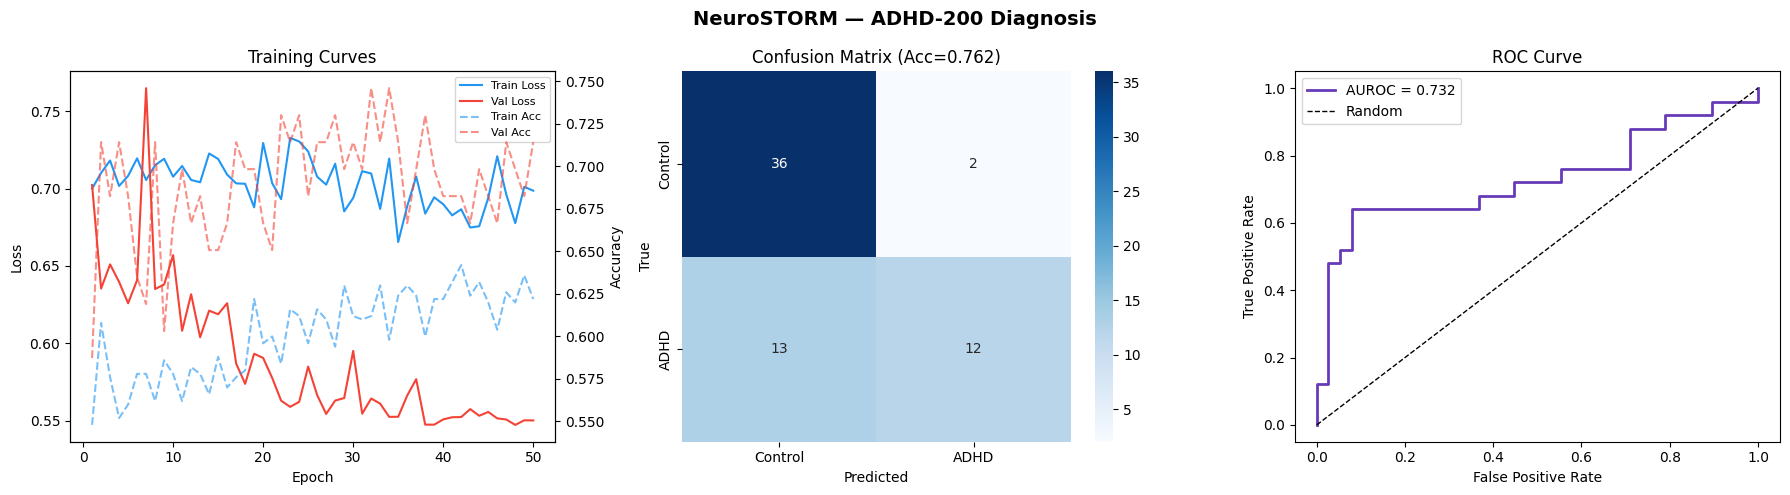

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('NeuroSTORM — ADHD-200 Diagnosis', fontsize=14, fontweight='bold')

# ── 1. Training curves ───────────────────────────────────────────────────────
ax = axes[0]
epochs = range(1, len(history['train_loss']) + 1)
ax.plot(epochs, history['train_loss'], label='Train Loss', color='#2196F3')
ax.plot(epochs, history['val_loss'],   label='Val Loss',   color='#F44336')
ax2 = ax.twinx()
ax2.plot(epochs, history['train_acc'], label='Train Acc', color='#2196F3',
         linestyle='--', alpha=0.6)
ax2.plot(epochs, history['val_acc'],   label='Val Acc',   color='#F44336',
         linestyle='--', alpha=0.6)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax2.set_ylabel('Accuracy')
ax.set_title('Training Curves')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

# ── 2. Confusion Matrix ──────────────────────────────────────────────────────
ax = axes[1]
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Control','ADHD'],
            yticklabels=['Control','ADHD'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix (Acc={acc:.3f})')

# ── 3. ROC Curve ─────────────────────────────────────────────────────────────
ax = axes[2]
try:
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    ax.plot(fpr, tpr, color='#673AB7', lw=2, label=f'AUROC = {auc:.3f}')
    ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve')
    ax.legend()
except Exception:
    ax.text(0.5, 0.5, 'ROC unavailable\n(single class in test set)',
            ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score

test_meta = manifest_final[manifest_final['split'] == 'test'].reset_index(drop=True)
test_meta = test_meta.iloc[:len(all_labels)].copy()
test_meta['pred']  = all_preds
test_meta['prob']  = all_probs
test_meta['true']  = all_labels

rows = []
for site, grp in test_meta.groupby('site'):
    acc_s = accuracy_score(grp['true'], grp['pred'])
    try:
        auc_s = roc_auc_score(grp['true'], grp['prob'])
    except Exception:
        auc_s = float('nan')
    rows.append({'Site': site, 'N': len(grp), 'Accuracy': acc_s, 'AUROC': auc_s,
                 'ADHD': int(grp['true'].sum()), 'Control': int((grp['true']==0).sum())})

site_df = pd.DataFrame(rows).sort_values('Accuracy', ascending=False)
print(site_df.to_string(index=False, float_format='{:.3f}'.format))

      Site  N  Accuracy  AUROC  ADHD  Control
     Brown  1     1.000    NaN     1        0
Pittsburgh 13     0.923    NaN     0       13
  Peking_1  8     0.875  1.000     1        7
       KKI  9     0.778  0.500     2        7
       NYU 20     0.700  0.736    13        7
NeuroIMAGE  8     0.625  0.750     6        2
      OHSU  4     0.500  0.250     2        2


/home/nvidia/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/nvidia/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [21]:
import os

# Check the NeuroSTORM GitHub releases page for the current download URL:
# https://github.com/CUHK-AIM-Group/NeuroSTORM/releases

os.makedirs('./pretrained_models', exist_ok=True)

# Replace URL below with the actual release asset URL from the repo
CKPT_URL = 'https://github.com/CUHK-AIM-Group/NeuroSTORM/releases/download/v1.0/neurostorm_mae.pth'
CKPT_PATH = './pretrained_models/neurostorm_mae.pth'

if not os.path.exists(CKPT_PATH):
    print(f'Downloading pretrained checkpoint...')
    os.system(f'wget -q --show-progress -O {CKPT_PATH} "{CKPT_URL}"')
    if os.path.exists(CKPT_PATH):
        size_mb = os.path.getsize(CKPT_PATH) / 1e6
        print(f'✅ Downloaded {size_mb:.0f} MB → {CKPT_PATH}')
    else:
        print('❌ Download failed. Check the URL on the GitHub releases page.')
else:
    print(f'✅ Checkpoint already exists: {CKPT_PATH}')

# After downloading, re-run Cell 13 to load the weights.

✅ Checkpoint already exists: ./pretrained_models/neurostorm_mae.pth
